In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
from Soccer_OCEL.utils import formatting

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [2]:
path='data/28196177'
games=get_games(path)
Game='J03WQQ'
GameData=load_game_data(path, Game, simplified=True)
GameData=assign_roles_multi(GameData, team=True)
GameData = formatting(GameData)
allgame_df=GameData.events

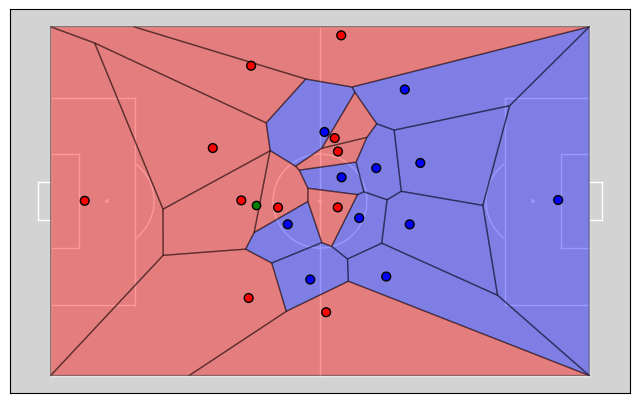

In [31]:
frame_voronoi_plot(GameData.positions, GameData.pitch, frame=22, session=1)
#save_voronoi_frames(GameData.positions, GameData.pitch, session=1, out_dir=f"{Game}_session1_step10", step=10)
#make_animation_from_frames(out_dir="frames_session1_step100", output="voronoi_session1.gif", fps=6)

In [3]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))&(allgame_df['attribute:team'].str.contains('Home'))]
#shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))]
shot_df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
event_log = pm4py.convert_to_event_log(shot_df)

In [71]:
eventdf_home=eventdf[eventdf['attribute:team'].str.contains('Home')]
eventdf_home=eventdf_home[~eventdf_home['attribute:attacking_team'].isna()]
eventdf_home_df = eventdf[eventdf['case:concept:name'].isin(eventdf_home['case:concept:name'])]
event_log = pm4py.convert_to_event_log(eventdf_home_df)

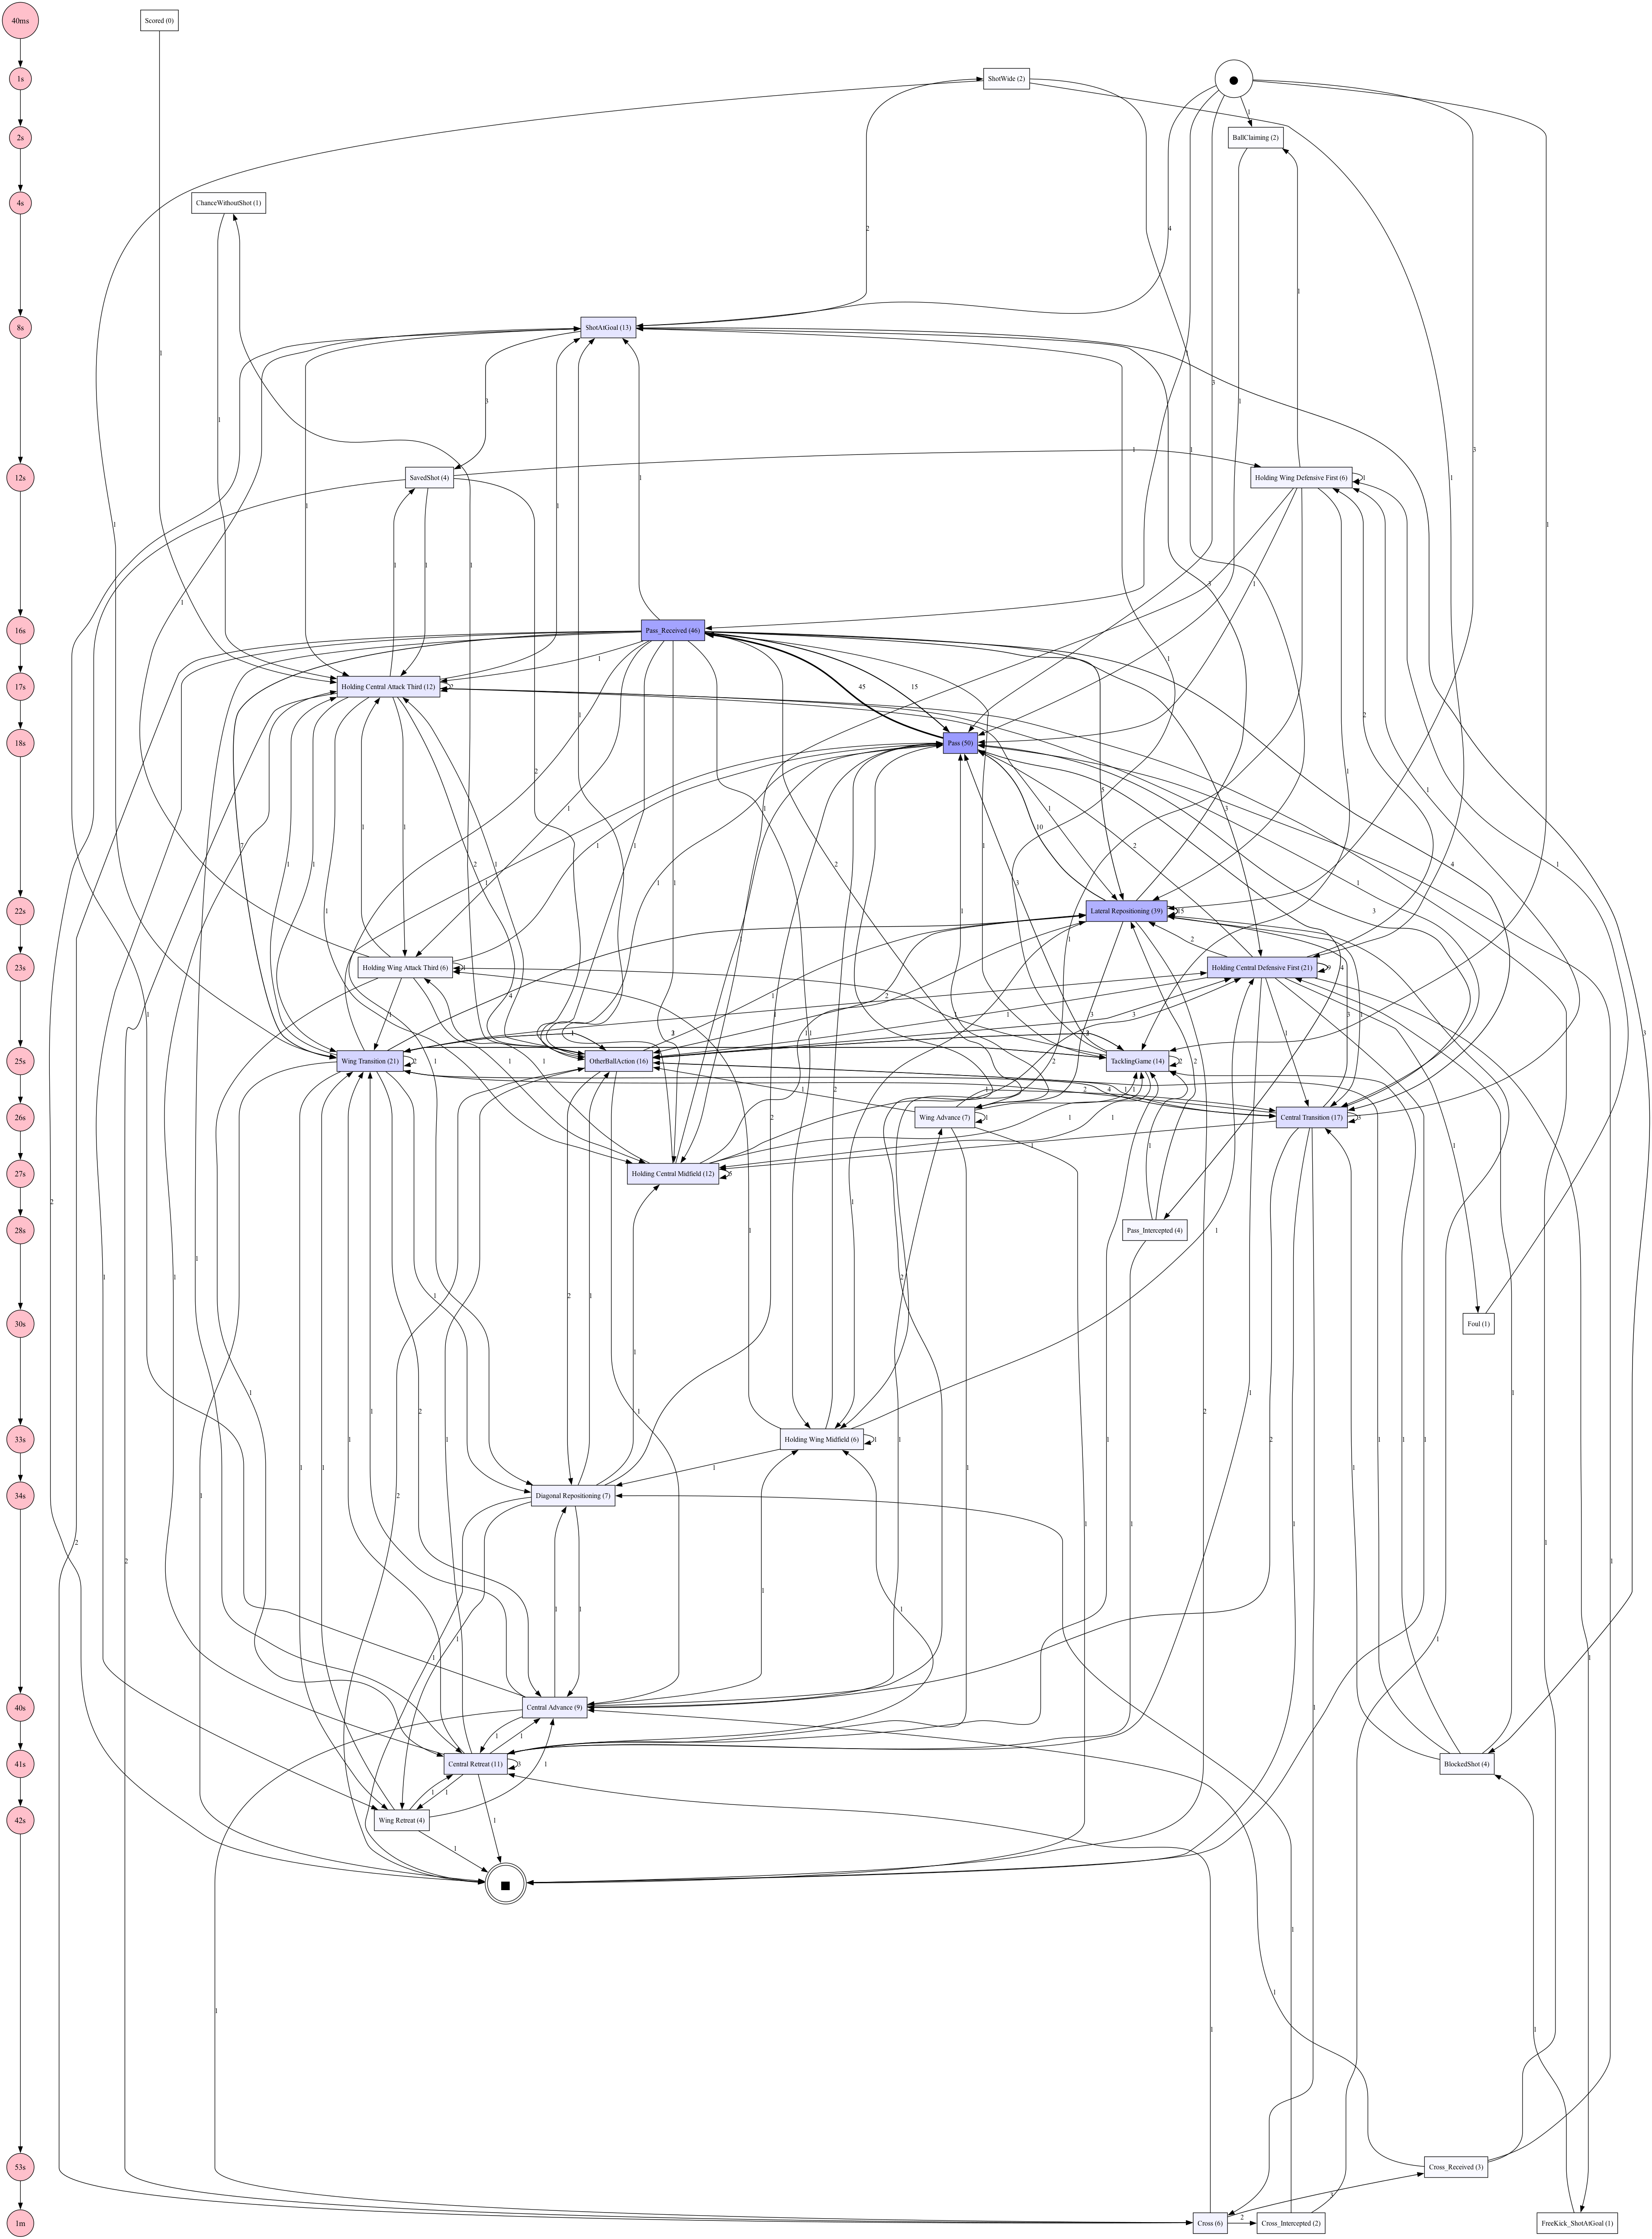

In [4]:
#log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
#log = shot_df[~shot_df['Goalkeeper'].isna()]
log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log)
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'Central Advance' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")


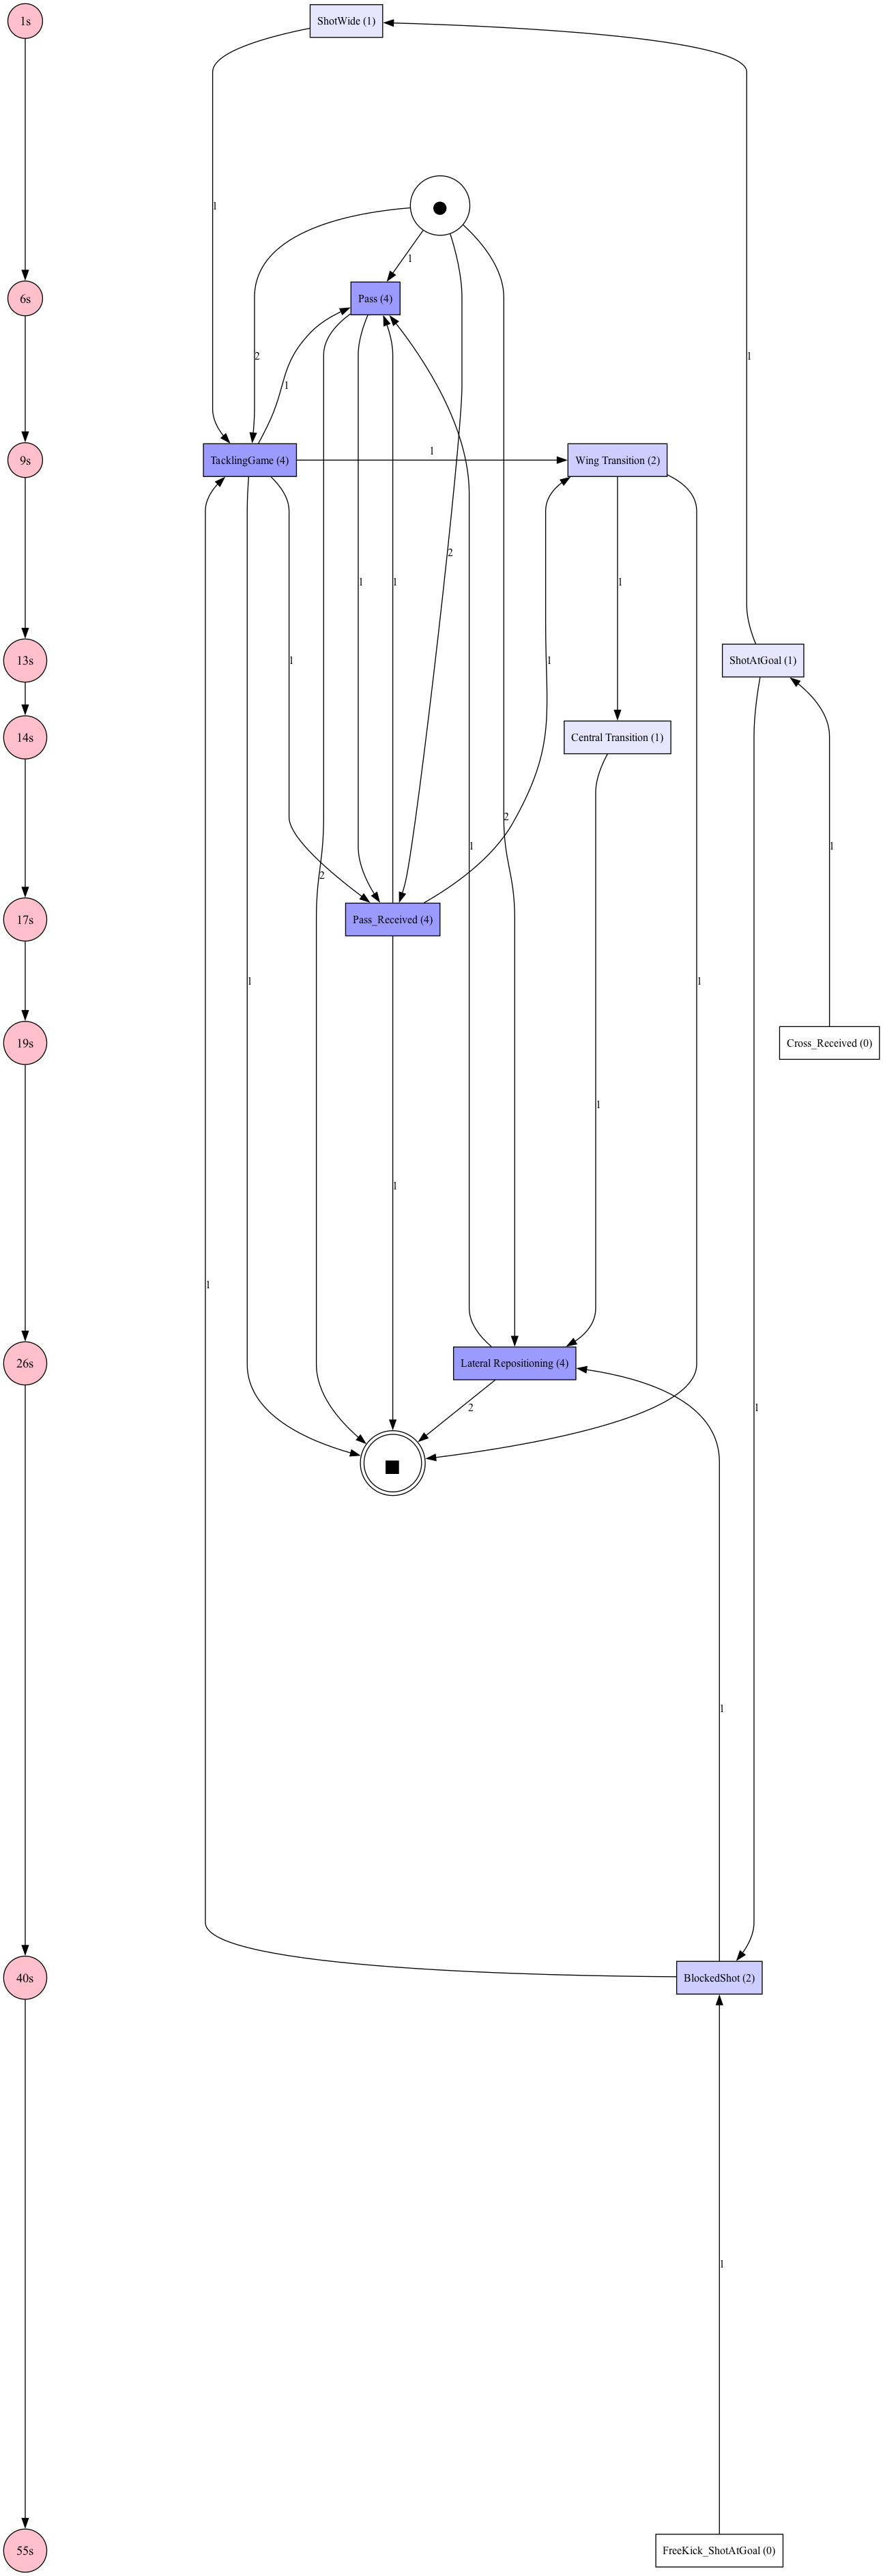

In [10]:
log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
#log = shot_df[~shot_df['Goalkeeper'].isna()]
#log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log)
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

In [ ]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=['attacking_team', 'defending_team']#['Team','Player','Session', 'case:concept:name']
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    ])

In [6]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=["Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     #,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     ]#['Team','Player','Session', 'case:concept:name']
                                        , obj_separator=';'
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])

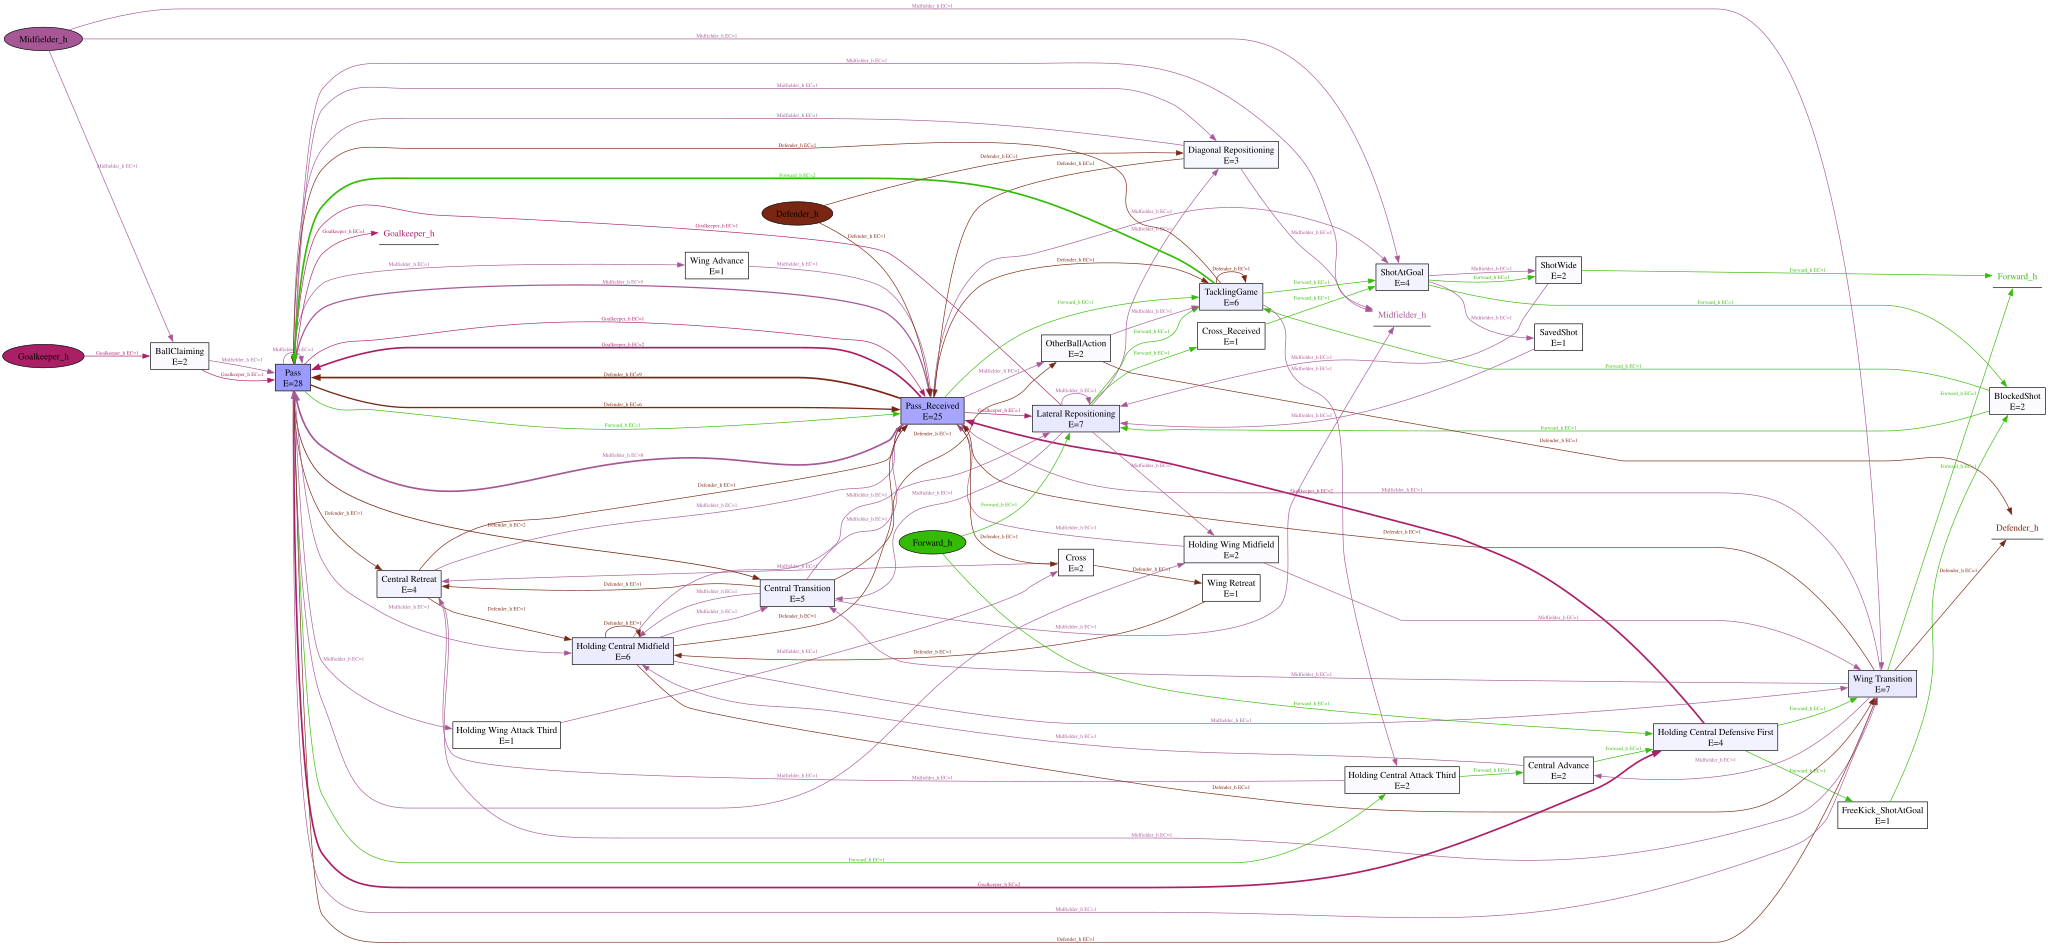

In [7]:
dfg=pm4py.ocel.discover_ocdfg(ocel)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)